<a href="https://colab.research.google.com/github/HariSharma10/Machine_Leaning/blob/main/Titanic_Survival_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')
print(df.head())
print(df.info())
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

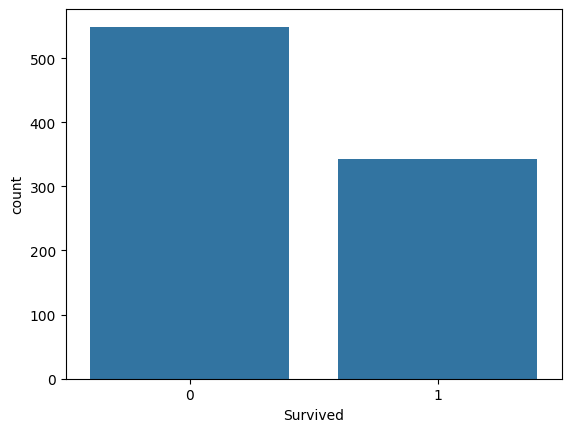

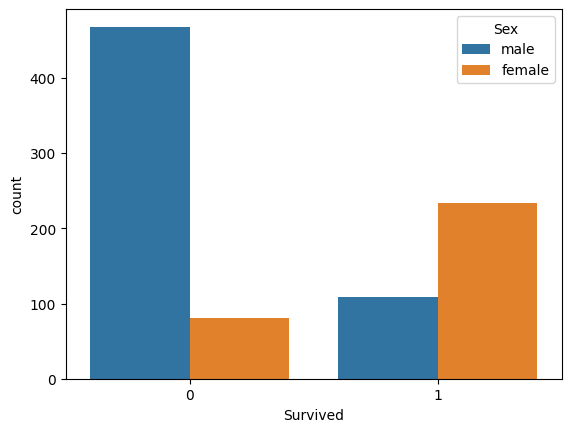

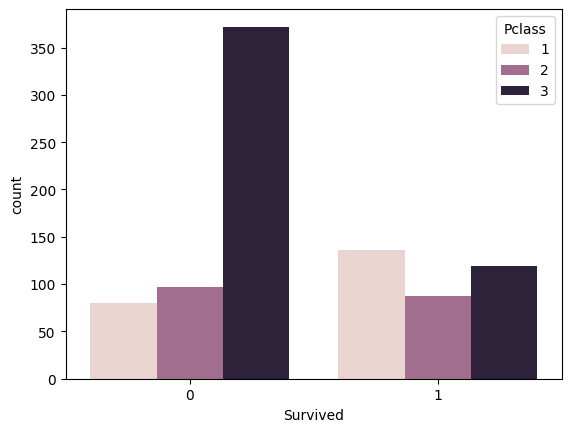

In [3]:
sns.countplot(data=df, x='Survived')
plt.show()

sns.countplot(data=df, x='Survived', hue='Sex')
plt.show()

sns.countplot(data=df, x='Survived', hue='Pclass')
plt.show()

In [4]:
# Drop columns that aren't useful as-is
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

X = df.drop('Survived', axis=1)
y = df['Survived']

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(include='object').columns.tolist()

print("Numeric:", num_features)
print("Categorical:", cat_features)

Numeric: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical: ['Sex', 'Embarked']


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
        ])
cat_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
                ])
preprocessor = ColumnTransformer([
                    ('num', num_pipeline, num_features),
                        ('cat', cat_pipeline, cat_features)
                        ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



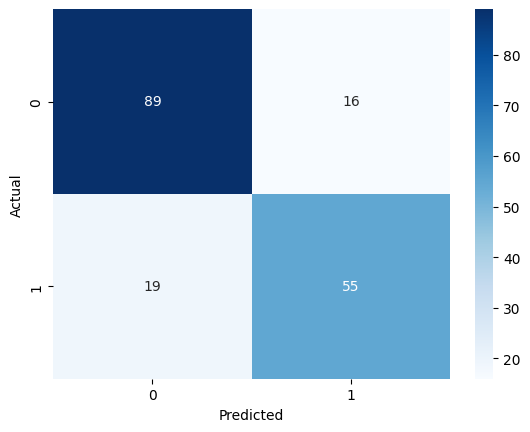

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [8]:
importances = model.named_steps['classifier'].feature_importances_
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feat_imp.head(10))

num__Fare          0.254019
num__Age           0.246791
cat__Sex_male      0.156898
cat__Sex_female    0.134643
num__Pclass        0.085388
num__SibSp         0.048399
num__Parch         0.038618
cat__Embarked_S    0.014841
cat__Embarked_C    0.012768
cat__Embarked_Q    0.007635
dtype: float64


In [12]:
import pandas as pd

# Enter passenger details (must match training columns exactly)
new_passenger = pd.DataFrame([{
    'Pclass': 1,          # 1st, 2nd, or 3rd class
        'Sex': 'female',
            'Age': 29,
                'SibSp': 0,           # siblings/spouses aboard
                    'Parch': 0,           # parents/children aboard
                        'Fare': 100.0,
                            'Embarked': 'S'       # C = Cherbourg, Q = Queenstown, S = Southampton
                            }])

prediction = model.predict(new_passenger)
probability = model.predict_proba(new_passenger)

result = "Survived" if prediction[0] == 1 else "Did not survive"
print(f"Prediction: {result}")
print(f"Survival probability: {probability[0][1]*100:.2f}%")

Prediction: Survived
Survival probability: 100.00%
